# ATAM-FET: Adaptive Toxic Attention Module for Toxicity Detection

**DistilBERT + ATAM** — Multi-label toxic comment classification with learnable token-level attention.

### Architecture
- **DistilBERT** encoder → hidden states `(batch, seq_len, 768)`
- **ATAM**: learnable energy `e_i = v^T tanh(W h_i + b)`, softmax attention `α_i`, weighted sum `z = Σ α_i h_i`
- **Classifier**: `concat([CLS], z)` → Dropout → Linear(1536 → 6) → sigmoid

### Dataset: Jigsaw Toxic Comment Classification (Kaggle)
- 159,571 training samples, 6 labels (toxic, severe_toxic, obscene, threat, insult, identity_hate)
- 80/10/10 stratified train/val/test split

In [1]:
import os
import gc
import re
import math
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter
from typing import Optional, Tuple, List, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup,
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, confusion_matrix,
)

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU count: {torch.cuda.device_count()}')

Device: cuda
GPU count: 2


In [2]:
# ──────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────
CFG = {
    'model_name': 'distilbert-base-uncased',
    'max_seq_length': 256,
    'batch_size': 32,
    'epochs': 6,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_steps': 500,
    'gradient_clip': 1.0,
    'dropout': 0.1,
    'num_labels': 6,
    'seed': 42,
}

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Kaggle dataset path — fall back to local if not on Kaggle
KAGGLE_PATH = Path('/kaggle/input/datasets/najmus07/jigasaw-train')
LOCAL_PATH = Path('data/raw')
if KAGGLE_PATH.exists():
    DATA_PATH = KAGGLE_PATH
    print(f'Kaggle dataset detected: {DATA_PATH}')
else:
    DATA_PATH = LOCAL_PATH
    print(f'Using local data: {DATA_PATH}')

Kaggle dataset detected: /kaggle/input/datasets/najmus07/jigasaw-train


---
## 1. Data Loading & Cleaning

In [3]:
def load_and_clean_data():
    df = pd.read_csv(DATA_PATH / 'train.csv')
    print(f'Raw samples: {len(df):,}')

    def clean_text(text: str) -> str:
        if not isinstance(text, str):
            return ''
        text = re.sub(r'https?://\S+|www\.\S+', '', text, flags=re.IGNORECASE)
        text = re.sub(r'@\S+', '', text, flags=re.IGNORECASE)
        try:
            import emoji
            text = emoji.demojize(text)
        except ImportError:
            pass
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text if text else '[no_text]'

    df['clean_text'] = df['comment_text'].apply(clean_text)
    before = len(df)
    df = df.drop_duplicates(subset=['clean_text'], keep='first')
    print(f'Duplicates removed: {before - len(df)}')
    print(f'Cleaned samples: {len(df):,}')

    for col in LABEL_COLS:
        pct = df[col].mean() * 100
        print(f'  {col:<16s} {int(df[col].sum()):6d} positive ({pct:.2f}%)')

    return df


df = load_and_clean_data()

Raw samples: 159,571
Duplicates removed: 282
Cleaned samples: 159,289
  toxic             15246 positive (9.57%)
  severe_toxic       1590 positive (1.00%)
  obscene            8420 positive (5.29%)
  threat              474 positive (0.30%)
  insult             7850 positive (4.93%)
  identity_hate      1397 positive (0.88%)


## 2. Train/Val/Test Split (Stratified)

In [4]:
from sklearn.model_selection import train_test_split

stratify = (df[LABEL_COLS].sum(axis=1) > 0).astype(int)
df_train, df_temp = train_test_split(
    df, test_size=0.2, random_state=CFG['seed'], stratify=stratify,
)
stratify_temp = (df_temp[LABEL_COLS].sum(axis=1) > 0).astype(int)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=CFG['seed'], stratify=stratify_temp,
)

print(f'Train: {len(df_train):,} ({100*len(df_train)/len(df):.1f}%)')
print(f'Val:   {len(df_val):,} ({100*len(df_val)/len(df):.1f}%)')
print(f'Test:  {len(df_test):,} ({100*len(df_test)/len(df):.1f}%)')

for col in LABEL_COLS:
    print(f'  {col:<16s} trn={df_train[col].mean()*100:.2f}%  val={df_val[col].mean()*100:.2f}%  tst={df_test[col].mean()*100:.2f}%')

Train: 127,431 (80.0%)
Val:   15,929 (10.0%)
Test:  15,929 (10.0%)
  toxic            trn=9.57%  val=9.58%  tst=9.57%
  severe_toxic     trn=0.98%  val=1.10%  tst=1.02%
  obscene          trn=5.28%  val=5.52%  tst=5.08%
  threat           trn=0.29%  val=0.31%  tst=0.31%
  insult           trn=4.91%  val=5.20%  tst=4.84%
  identity_hate    trn=0.89%  val=0.77%  tst=0.91%


## 3. Tokenization

In [5]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Vocab size: {tokenizer.vocab_size:,}')


class ToxicDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=CFG['max_seq_length'],
            return_tensors='pt',
        )
        item = {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


train_ds = ToxicDataset(df_train['clean_text'].tolist(), df_train[LABEL_COLS].values)
val_ds = ToxicDataset(df_val['clean_text'].tolist(), df_val[LABEL_COLS].values)
test_ds = ToxicDataset(df_test['clean_text'].tolist(), df_test[LABEL_COLS].values)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size']*2, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size']*2, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 30,522
Train batches: 3983
Val batches:   249
Test batches:  249


## 4. ATAM Model Definition

In [6]:
class AdaptiveToxicAttentionModule(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size, bias=True)
        self.v = nn.Linear(hidden_size, 1, bias=False)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)
        nn.init.xavier_uniform_(self.v.weight)

    def forward(self, hidden_states, attention_mask):
        e = self.v(torch.tanh(self.W(hidden_states))).squeeze(-1)
        e = e.masked_fill(attention_mask.float() == 0, -1e9)
        alpha = F.softmax(e, dim=-1)
        z = torch.bmm(alpha.unsqueeze(1), hidden_states).squeeze(1)
        return z, alpha


class DistilBERTWithATAM(nn.Module):
    def __init__(self, model_name='distilbert-base-uncased',
                 num_labels=6, dropout=0.1):
        super().__init__()
        self.distilbert = AutoModel.from_pretrained(model_name)
        hidden_size = self.distilbert.config.hidden_size
        self.atam = AdaptiveToxicAttentionModule(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_labels)
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids, attention_mask=attention_mask)
        hs = outputs.last_hidden_state
        cls_out = hs[:, 0]
        toxic_repr, _ = self.atam(hs, attention_mask)
        combined = torch.cat([cls_out, toxic_repr], dim=-1)
        combined = self.dropout(combined)
        return self.classifier(combined)

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = DistilBERTWithATAM(
    model_name=CFG['model_name'],
    num_labels=CFG['num_labels'],
    dropout=CFG['dropout'],
)
model = model.to(DEVICE)
print(f'Model parameters: {model.get_num_params():,}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 66,963,462


## 5. Training Setup

In [7]:
def compute_pos_weight(labels):
    num_pos = labels.sum(axis=0)
    num_neg = labels.shape[0] - num_pos
    return torch.tensor(num_neg / np.maximum(num_pos, 1), dtype=torch.float32)


pos_weight = compute_pos_weight(df_train[LABEL_COLS].values)
for name, w in zip(LABEL_COLS, pos_weight.tolist()):
    print(f'  {name:<16s} pos_weight={w:.2f}')


no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]

optimizer = torch.optim.AdamW(optimizer_grouped, lr=CFG['learning_rate'])

total_steps = len(train_loader) * CFG['epochs']
warmup_steps = min(CFG['warmup_steps'], total_steps // 10)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps,
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

  toxic            pos_weight=9.45
  severe_toxic     pos_weight=100.70
  obscene          pos_weight=17.93
  threat           pos_weight=338.82
  insult           pos_weight=19.39
  identity_hate    pos_weight=111.87


## 6. Metrics

In [8]:
def compute_metrics(logits, labels):
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(np.float32)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall': recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
        'roc_auc': np.mean([
            roc_auc_score(labels[:, i], probs[:, i])
            for i in range(labels.shape[1])
        ]),
        'hamming_loss': hamming_loss(labels, preds),
    }


def generate_cm(logits, labels, label_names, save_path=None):
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(np.int32)
    labels_int = labels.astype(np.int32)
    n = len(label_names)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for i, name in enumerate(label_names):
        cm = confusion_matrix(labels_int[:, i], preds[:, i], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        tn, fp, fn, tp = cm.ravel()
        prec = tp / (tp+fp) if (tp+fp) > 0 else 0
        rec = tp / (tp+fn) if (tp+fn) > 0 else 0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        axes[i].set_title(f'{name}\nP={prec:.3f} R={rec:.3f} F1={f1:.3f}')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 7. Training Loop

In [9]:
history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': [], 'val_accuracy': []}
best_f1 = 0.0

for epoch in range(CFG['epochs']):
    model.train()
    total_loss = 0.0
    progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG["epochs"]}')

    for batch in progress:
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        logits = model(ids, mask)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG['gradient_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            logits = model(ids, mask)
            loss = loss_fn(logits, labels)
            val_loss += loss.item()
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    val_metrics = compute_metrics(all_logits, all_labels)
    avg_val_loss = val_loss / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_accuracy'].append(val_metrics['accuracy'])

    print(f'\nEpoch {epoch+1}: train_loss={avg_train_loss:.4f} '
          f'val_loss={avg_val_loss:.4f} val_acc={val_metrics["accuracy"]:.4f} '
          f'val_f1={val_metrics["f1_macro"]:.4f} lr={scheduler.get_last_lr()[0]:.2e}')

    if val_metrics['f1_macro'] > best_f1:
        best_f1 = val_metrics['f1_macro']
        torch.save(model.state_dict(), 'best_atam_model.pt')
        print(f'  New best model saved (F1={best_f1:.4f})')

Epoch 1/6:   0%|          | 0/3983 [00:00<?, ?it/s]


Epoch 1: train_loss=0.4730 val_loss=0.3177 val_acc=0.8773 val_f1=0.6068 lr=1.70e-05
  New best model saved (F1=0.6068)


Epoch 2/6:   0%|          | 0/3983 [00:00<?, ?it/s]


Epoch 2: train_loss=0.2901 val_loss=0.2899 val_acc=0.8874 val_f1=0.5968 lr=1.36e-05


Epoch 3/6:   0%|          | 0/3983 [00:00<?, ?it/s]

...


Epoch 4: train_loss=0.1382 val_loss=0.8792 val_acc=0.9195 val_f1=0.6801 lr=6.81e-06
  New best model saved (F1=0.6801)


Epoch 5/6:   0%|          | 0/3983 [00:00<?, ?it/s]


Epoch 5: train_loss=0.0962 val_loss=0.8851 val_acc=0.9160 val_f1=0.6715 lr=3.40e-06


Epoch 6/6:   0%|          | 0/3983 [00:00<?, ?it/s]


Epoch 6: train_loss=0.0705 val_loss=1.0051 val_acc=0.9178 val_f1=0.6672 lr=0.00e+00


## 8. Training Curves

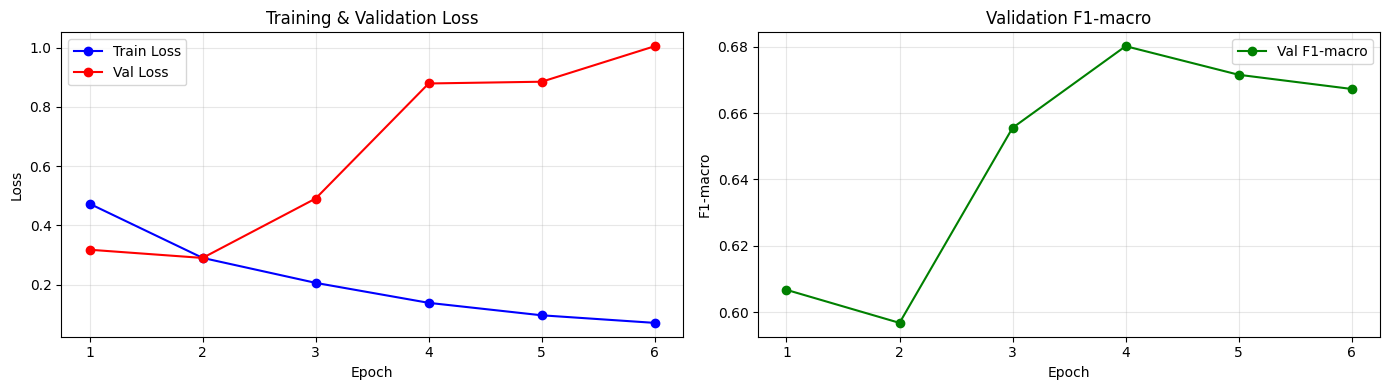

In [10]:
epochs = range(1, CFG['epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_f1_macro'], 'g-o', label='Val F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-macro')
axes[1].set_title('Validation F1-macro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('atam_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

In [11]:
print('=' * 60)
print('TEST SET EVALUATION')
print('=' * 60)

model.load_state_dict(torch.load('best_atam_model.pt', map_location=DEVICE))
model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        logits = model(ids, mask)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_logits = np.concatenate(all_logits, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
test_metrics = compute_metrics(all_logits, all_labels)

print(f'\n  Subset Accuracy:  {test_metrics["accuracy"]:.4f}')
print(f'  Micro F1:         {test_metrics["f1_micro"]:.4f}')
print(f'  Macro F1:         {test_metrics["f1_macro"]:.4f}')
print(f'  ROC-AUC:          {test_metrics["roc_auc"]:.4f}')
print(f'  Hamming Loss:     {test_metrics["hamming_loss"]:.4f}')

TEST SET EVALUATION


Testing:   0%|          | 0/249 [00:00<?, ?it/s]


  Subset Accuracy:  0.9163
  Micro F1:         0.7713
  Macro F1:         0.6818
  ROC-AUC:          0.9878
  Hamming Loss:     0.0184


## 10. Per-Label Results & Confusion Matrices

Label             Precision     Recall         F1    ROC-AUC  Support
----------------------------------------------------------------
toxic                0.7626     0.8766     0.8156     0.9865     1524
severe_toxic         0.4269     0.6667     0.5205     0.9922      162
obscene              0.7306     0.9085     0.8099     0.9904      809
threat               0.5818     0.6531     0.6154     0.9872       49
insult               0.6845     0.8444     0.7561     0.9834      771
identity_hate        0.4902     0.6897     0.5731     0.9873      145


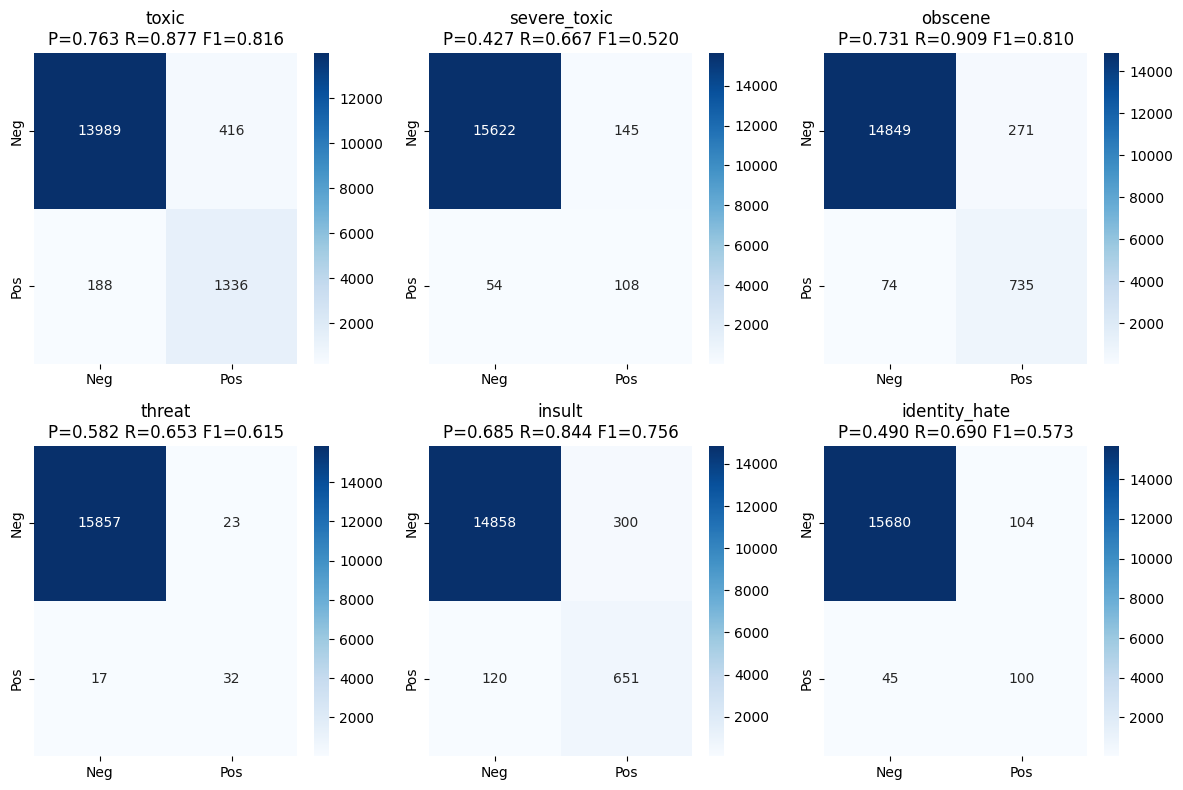

In [12]:
probs = 1.0 / (1.0 + np.exp(-all_logits))
preds = (probs >= 0.5).astype(np.float32)

print(f'{"Label":<16s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s} {"ROC-AUC":>10s} {"Support":>8s}')
print('-' * 64)
for i, name in enumerate(LABEL_COLS):
    p = precision_score(all_labels[:, i], preds[:, i], zero_division=0)
    r = recall_score(all_labels[:, i], preds[:, i], zero_division=0)
    f = f1_score(all_labels[:, i], preds[:, i], zero_division=0)
    auc = roc_auc_score(all_labels[:, i], probs[:, i])
    sup = int(all_labels[:, i].sum())
    print(f'{name:<16s} {p:>10.4f} {r:>10.4f} {f:>10.4f} {auc:>10.4f} {sup:>8d}')

generate_cm(all_logits, all_labels, LABEL_COLS, save_path='atam_confusion_matrices.png')

## 11. Summary & Comparison

### DistilBERT + ATAM Test Results

In [13]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'\nModel: DistilBERT + ATAM')
print(f'Parameters: {model.get_num_params():,}')
print(f'Best val F1-macro: {best_f1:.4f}')
print(f'\nTest set metrics:')
for k, v in test_metrics.items():
    print(f'  {k:20s}: {v:.4f}')
print(f'\nFiles saved:')
print(f'  - best_atam_model.pt')
print(f'  - atam_training_curves.png')
print(f'  - atam_confusion_matrices.png')

FINAL SUMMARY

Model: DistilBERT + ATAM
Parameters: 66,963,462
Best val F1-macro: 0.6801

Test set metrics:
  accuracy            : 0.9163
  precision           : 0.6128
  recall              : 0.7732
  f1_macro            : 0.6818
  f1_micro            : 0.7713
  roc_auc             : 0.9878
  hamming_loss        : 0.0184

Files saved:
  - best_atam_model.pt
  - atam_training_curves.png
  - atam_confusion_matrices.png
